In [1]:
import pandas as pd # For DataFrames, Series, and reading csv data in.
import seaborn as sns # Graphing, built ontop of MatPlot for ease-of-use and nicer diagrams.
import matplotlib.pyplot as plt # MatPlotLib for graphing data visually. Seaborn more likely to be used.
import numpy as np # For manipulating arrays and changing data into correct formats for certain libraries
from sklearn.model_selection import train_test_split
%matplotlib inline
from sklearn.preprocessing import StandardScaler  # For Normalization

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from imblearn.under_sampling import RandomUnderSampler

In [4]:
 flow_dataset = pd.read_csv('Dataset.csv')

        # flow_dataset.iloc[:, 2] = flow_dataset.iloc[:, 2].str.replace('.', '')
        # flow_dataset.iloc[:, 3] = flow_dataset.iloc[:, 3].str.replace('.', '')
        # flow_dataset.iloc[:, 5] = flow_dataset.iloc[:, 5].str.replace('.', '')
 flow_datasetn = flow_dataset[
            ['tp_src', 'ip_dst', 'tp_dst', 'ip_proto', 'icmp_code', 'icmp_type', 'flow_duration_sec',
             'flow_duration_nsec', 'idle_timeout', 'hard_timeout', 'flags', 'packet_count', 'byte_count',
             'packet_count_per_second', 'packet_count_per_nsecond', 'byte_count_per_second', 'byte_count_per_nsecond',
             'label']]
        # flow_datasetn.iloc[:, 0] = flow_datasetn.iloc[:, 0].str.replace('.', '')
 flow_datasetn.iloc[:, 1] = flow_datasetn.iloc[:, 1].str.replace('.', '')
 X_flow = flow_datasetn.iloc[:, :-1].values
 X_flow = X_flow.astype('float64')
 rus = RandomUnderSampler(random_state=42)

 y_flow = flow_datasetn.iloc[:, -1].values

 X_flow_train, X_flow_test, y_flow_train, y_flow_test = train_test_split(X_flow, y_flow, test_size=0.25,
                                                                                random_state=0)

 X_train_rus, y_train_rus = rus.fit_resample(X_flow_train, y_flow_train)

 classifier = RandomForestClassifier(n_estimators=10, criterion="entropy", random_state=0)
 flow_model = classifier.fit(X_train_rus, y_train_rus)

 y_flow_test_pred = flow_model.predict(X_flow_test)
 y_flow_train_pred= flow_model.predict(X_flow_train)

In [5]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
test_accuracy = accuracy_score(y_flow_test, y_flow_test_pred )
train_accuracy = accuracy_score(y_flow_train, y_flow_train_pred)

print("Training Accuracy:", train_accuracy * 100)
print("Test Accuracy:", test_accuracy * 100)

Training Accuracy: 99.99607076719124
Test Accuracy: 99.99538743023489


In [6]:
from sklearn.metrics import classification_report
print(classification_report(y_flow_test,  y_flow_test_pred ))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33544
           1       1.00      1.00      1.00    161575

    accuracy                           1.00    195119
   macro avg       1.00      1.00      1.00    195119
weighted avg       1.00      1.00      1.00    195119


In [29]:
###################################Neural Network
import keras
from keras import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy
sc=StandardScaler()

X_train_rus = sc.fit_transform(X_train_rus)
X_flow_test = sc.transform(X_flow_test)

nn_model = Sequential([
    Dense(units=64, activation='relu'),
    Dense(units=32, activation='relu'),
    Dense(units=1, activation='sigmoid')  #output layer  
])
nn_model.compile(optimizer='adam', loss='BinaryCrossentropy', metrics=['accuracy'])
history = nn_model.fit(X_train_rus, y_train_rus, epochs=50, batch_size=10000, validation_data=(X_flow_test, y_flow_test))

Epoch 1/50
21/21 [==============================] - 1s 13ms/step - loss: 0.5852 - accuracy: 0.7891 - val_loss: 0.5062 - val_accuracy: 0.9207
Epoch 2/50
21/21 [==============================] - 0s 8ms/step - loss: 0.3894 - accuracy: 0.9410 - val_loss: 0.3138 - val_accuracy: 0.9627
Epoch 3/50
21/21 [==============================] - 0s 8ms/step - loss: 0.2286 - accuracy: 0.9591 - val_loss: 0.1649 - val_accuracy: 0.9758
Epoch 4/50
21/21 [==============================] - 0s 8ms/step - loss: 0.1246 - accuracy: 0.9778 - val_loss: 0.0925 - val_accuracy: 0.9911
Epoch 5/50
21/21 [==============================] - 0s 8ms/step - loss: 0.0722 - accuracy: 0.9905 - val_loss: 0.0545 - val_accuracy: 0.9975
Epoch 6/50
21/21 [==============================] - 0s 8ms/step - loss: 0.0469 - accuracy: 0.9948 - val_loss: 0.0378 - val_accuracy: 0.9986
Epoch 7/50
21/21 [==============================] - 0s 9ms/step - loss: 0.0334 - accuracy: 0.9970 - val_loss: 0.0271 - val_accuracy: 0.9991
Epoch 8/50
21/21 [=

In [30]:
acc=nn_model.evaluate(X_flow_test,y_flow_test,batch_size=10000)

20/20 [==============================] - 0s 3ms/step - loss: 0.0038 - accuracy: 0.9989


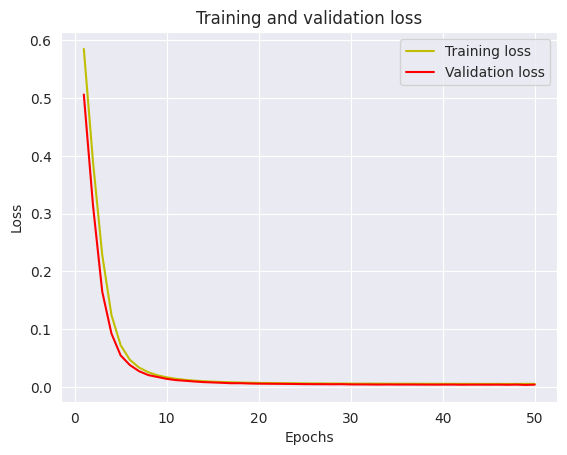

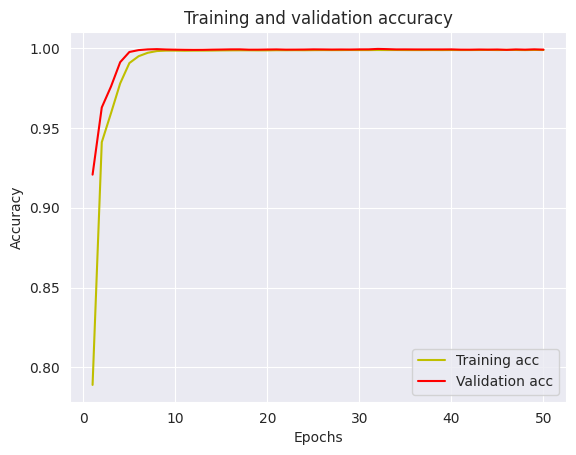

In [31]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [16]:
ytest_p=nn_model.predict(X_flow_test)
def binary_converter(t):
    for i in range(len(t)):
        if (abs(t[i])>=0.5):
            t[i]=1
        elif (abs(t[i])<=0.5):
            t[i]=0
    return t
ytest_p=binary_converter(ytest_p)
from sklearn.metrics import classification_report
print(classification_report(y_flow_test, ytest_p))

6098/6098 [==============================] - 7s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33544
           1       1.00      1.00      1.00    161575

    accuracy                           1.00    195119
   macro avg       1.00      1.00      1.00    195119
weighted avg       1.00      1.00      1.00    195119


In [18]:
##################XGBoost
import xgboost as xgb
xgb_model=xgb.XGBClassifier(random_state=0)
xgb_model.fit(X_train_rus,y_train_rus)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=0, ...)

In [24]:
ytest_p=xgb_model.predict(X_flow_test)
ytrain_p=xgb_model.predict(X_train_rus)

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
# Calculate accuracy
test_accuracy = accuracy_score(y_flow_test, ytest_p)
train_accuracy = accuracy_score(y_train_rus, ytrain_p)

print("Training Accuracy:", train_accuracy*100)
print("Test Accuracy:", test_accuracy*100)
print(classification_report(y_flow_test, ytest_p))

Training Accuracy: 99.99950066411672
Test Accuracy: 99.99692495348992
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33544
           1       1.00      1.00      1.00    161575

    accuracy                           1.00    195119
   macro avg       1.00      1.00      1.00    195119
weighted avg       1.00      1.00      1.00    195119
